Three models
- Normal
- Normal with regularization term and the output layer (the best).
- More complicated network to increase train accuracy.

In [1]:
## import some dependencies
## import some dependencies
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

In [2]:
# Load the data
data_train = pd.read_csv('Data/Water_Train_Data.txt', sep='\t')
data_cv = pd.read_csv('Data/Water_CV_Data.txt', sep='\t')
data_test = pd.read_csv('Data/Water_Test_Data.txt', sep='\t')

X_train = data_train.drop('is_safe', axis=1)
X_cv = data_cv.drop('is_safe', axis=1)
X_test = data_test.drop('is_safe', axis=1)

y_train = data_train['is_safe']
y_cv = data_cv['is_safe']
y_test = data_test['is_safe']

In [3]:
# Define the model
model = keras.Sequential([
    layers.Dense(32, activation='relu', input_shape=(X_train.shape[1],)),
    layers.Dense(16, activation='relu'),
    layers.Dense(1, activation='sigmoid')  # sigmoid because binary classification
])

# Compile the model
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

/Applications/anaconda3/envs/tf_env/lib/python3.10/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [4]:
# Train the model
history = model.fit(X_train, y_train, epochs=100, batch_size=8, validation_data=(X_cv, y_cv))

Epoch 1/100
600/600 ━━━━━━━━━━━━━━━━━━━━ 1s 505us/step - accuracy: 0.8513 - loss: 0.4174 - val_accuracy: 0.8844 - val_loss: 0.2910
Epoch 2/100
600/600 ━━━━━━━━━━━━━━━━━━━━ 0s 397us/step - accuracy: 0.8854 - loss: 0.2921 - val_accuracy: 0.8913 - val_loss: 0.2675
Epoch 3/100
600/600 ━━━━━━━━━━━━━━━━━━━━ 0s 396us/step - accuracy: 0.8904 - loss: 0.2649 - val_accuracy: 0.8888 - val_loss: 0.2607
Epoch 4/100
600/600 ━━━━━━━━━━━━━━━━━━━━ 0s 399us/step - accuracy: 0.8964 - loss: 0.2512 - val_accuracy: 0.8944 - val_loss: 0.2464
Epoch 5/100
600/600 ━━━━━━━━━━━━━━━━━━━━ 0s 402us/step - accuracy: 0.9041 - loss: 0.2374 - val_accuracy: 0.8994 - val_loss: 0.2421
Epoch 6/100
600/600 ━━━━━━━━━━━━━━━━━━━━ 0s 399us/step - accuracy: 0.9064 - loss: 0.2292 - val_accuracy: 0.9013 - val_loss: 0.2399
Epoch 7/100
600/600 ━━━━━━━━━━━━━━━━━━━━ 0s 395us/step - accuracy: 0.9128 - loss: 0.2240 - val_accuracy: 0.9013 - val_loss: 0.2504
Epoch 8/100
600/600 ━━━━━━━━━━━━━━━━━━━━ 0s 400us/step - accuracy: 0.9128 - loss: 0

In [5]:
cv_loss, cv_accuracy = model.evaluate(X_cv, y_cv)
print(f"Cross-validation accuracy: {cv_accuracy:.4f}")
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"Test accuracy: {test_accuracy:.4f}")

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 458us/step - accuracy: 0.9251 - loss: 0.2212
Cross-validation accuracy: 0.9394
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 436us/step - accuracy: 0.9327 - loss: 0.1892
Test accuracy: 0.9425


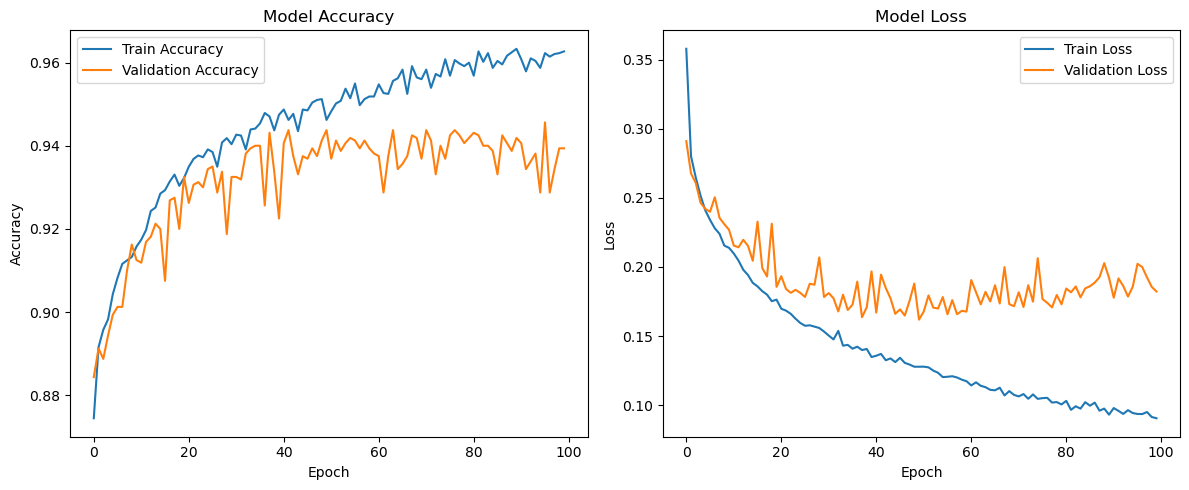

In [6]:
# Plot training & validation accuracy values
plt.figure(figsize=(12,5))

# Plot accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [45]:
from tensorflow.keras.regularizers import l2

# Define the model with regularization
model_regularized = keras.Sequential([
    layers.Dense(32, activation='relu', input_shape=(X_train.shape[1],)),
    layers.Dense(16, activation='relu'),
    layers.Dense(1, activation='sigmoid', kernel_regularizer=l2(0.01))  # sigmoid because binary classification
])

# Compile the model
model_regularized.compile(optimizer='adam',
                          loss='binary_crossentropy',
                          metrics=['accuracy'])

/Applications/anaconda3/envs/tf_env/lib/python3.10/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [46]:
# Train the model
history_regularized = model_regularized.fit(X_train, y_train, epochs=100, batch_size=8, validation_data=(X_cv, y_cv))

Epoch 1/100
600/600 ━━━━━━━━━━━━━━━━━━━━ 1s 528us/step - accuracy: 0.8277 - loss: 0.4386 - val_accuracy: 0.8844 - val_loss: 0.2918
Epoch 2/100
600/600 ━━━━━━━━━━━━━━━━━━━━ 0s 442us/step - accuracy: 0.8948 - loss: 0.2769 - val_accuracy: 0.8950 - val_loss: 0.2741
Epoch 3/100
600/600 ━━━━━━━━━━━━━━━━━━━━ 0s 412us/step - accuracy: 0.8994 - loss: 0.2594 - val_accuracy: 0.8956 - val_loss: 0.2551
Epoch 4/100
600/600 ━━━━━━━━━━━━━━━━━━━━ 0s 412us/step - accuracy: 0.9030 - loss: 0.2527 - val_accuracy: 0.8938 - val_loss: 0.2536
Epoch 5/100
600/600 ━━━━━━━━━━━━━━━━━━━━ 0s 411us/step - accuracy: 0.9059 - loss: 0.2430 - val_accuracy: 0.9031 - val_loss: 0.2518
Epoch 6/100
600/600 ━━━━━━━━━━━━━━━━━━━━ 0s 411us/step - accuracy: 0.9065 - loss: 0.2340 - val_accuracy: 0.9069 - val_loss: 0.2404
Epoch 7/100
600/600 ━━━━━━━━━━━━━━━━━━━━ 0s 416us/step - accuracy: 0.9009 - loss: 0.2454 - val_accuracy: 0.8994 - val_loss: 0.2518
Epoch 8/100
600/600 ━━━━━━━━━━━━━━━━━━━━ 0s 416us/step - accuracy: 0.9085 - loss: 0

In [47]:
cv_loss_regularized, cv_accuracy_regularized = model_regularized.evaluate(X_cv, y_cv)
print(f"Cross-validation accuracy (regularized): {cv_accuracy_regularized:.4f}")
test_loss_regularized, test_accuracy_regularized = model_regularized.evaluate(X_test, y_test)
print(f"Test accuracy: {test_accuracy_regularized:.4f}")

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 445us/step - accuracy: 0.9414 - loss: 0.1977
Cross-validation accuracy (regularized): 0.9544
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 409us/step - accuracy: 0.9304 - loss: 0.1968
Test accuracy: 0.9500


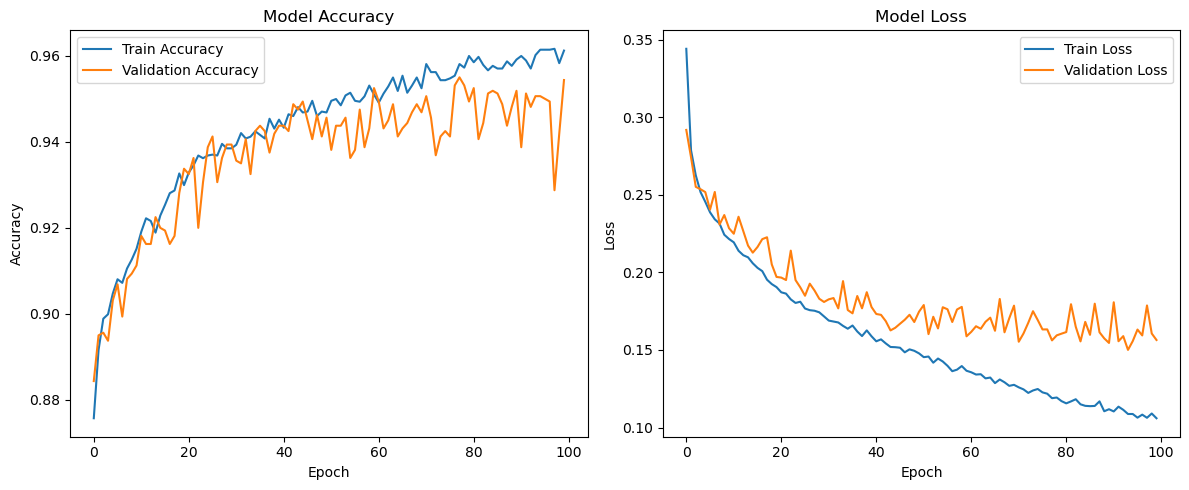

In [48]:
# Plot training & validation accuracy values
plt.figure(figsize=(12,5))

# Plot accuracy
plt.subplot(1,2,1)
plt.plot(history_regularized.history['accuracy'], label='Train Accuracy')
plt.plot(history_regularized.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot loss
plt.subplot(1,2,2)
plt.plot(history_regularized.history['loss'], label='Train Loss')
plt.plot(history_regularized.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [139]:
# Define the model with regularization
from tensorflow.keras.layers import Dropout

model_regularized_droupout = keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    layers.Dense(32, activation='relu'),
    layers.Dense(16, activation='relu'),
    layers.Dense(8, activation='relu'),
    layers.Dense(4, activation='relu', kernel_regularizer=l2(1.0)),
    layers.Dense(1, activation='sigmoid', kernel_regularizer=l2(10.0))
])
# Compile the model
model_regularized_droupout.compile(optimizer='adam',
                          loss='binary_crossentropy',
                          metrics=['accuracy'])

/Applications/anaconda3/envs/tf_env/lib/python3.10/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [140]:
history_regularized_droupout = model_regularized_droupout.fit(X_train, y_train, epochs=100, batch_size=8, validation_data=(X_cv, y_cv))

Epoch 1/100
600/600 ━━━━━━━━━━━━━━━━━━━━ 1s 580us/step - accuracy: 0.8824 - loss: 17.8938 - val_accuracy: 0.8844 - val_loss: 3.7797
Epoch 2/100
600/600 ━━━━━━━━━━━━━━━━━━━━ 0s 474us/step - accuracy: 0.8847 - loss: 2.4551 - val_accuracy: 0.8844 - val_loss: 0.5661
Epoch 3/100
600/600 ━━━━━━━━━━━━━━━━━━━━ 0s 471us/step - accuracy: 0.8944 - loss: 0.4412 - val_accuracy: 0.8844 - val_loss: 0.3332
Epoch 4/100
600/600 ━━━━━━━━━━━━━━━━━━━━ 0s 471us/step - accuracy: 0.8790 - loss: 0.3281 - val_accuracy: 0.8844 - val_loss: 0.3052
Epoch 5/100
600/600 ━━━━━━━━━━━━━━━━━━━━ 0s 469us/step - accuracy: 0.8817 - loss: 0.3041 - val_accuracy: 0.8844 - val_loss: 0.2854
Epoch 6/100
600/600 ━━━━━━━━━━━━━━━━━━━━ 0s 473us/step - accuracy: 0.8768 - loss: 0.2938 - val_accuracy: 0.8844 - val_loss: 0.2839
Epoch 7/100
600/600 ━━━━━━━━━━━━━━━━━━━━ 0s 519us/step - accuracy: 0.8755 - loss: 0.2812 - val_accuracy: 0.8900 - val_loss: 0.2689
Epoch 8/100
600/600 ━━━━━━━━━━━━━━━━━━━━ 0s 462us/step - accuracy: 0.8998 - loss: 

In [141]:
cv_loss_regularized_droupout, cv_accuracy_regularized_droupout = model_regularized_droupout.evaluate(X_cv, y_cv)
print(f"Cross-validation accuracy (regularized): {cv_accuracy_regularized_droupout:.4f}")
test_loss_regularized_droupout, test_accuracy_regularized_droupout = model_regularized_droupout.evaluate(X_test, y_test)
print(f"Test accuracy: {test_accuracy_regularized_droupout:.4f}")

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 463us/step - accuracy: 0.9130 - loss: 0.2485
Cross-validation accuracy (regularized): 0.9206
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 443us/step - accuracy: 0.9029 - loss: 0.2651
Test accuracy: 0.9112


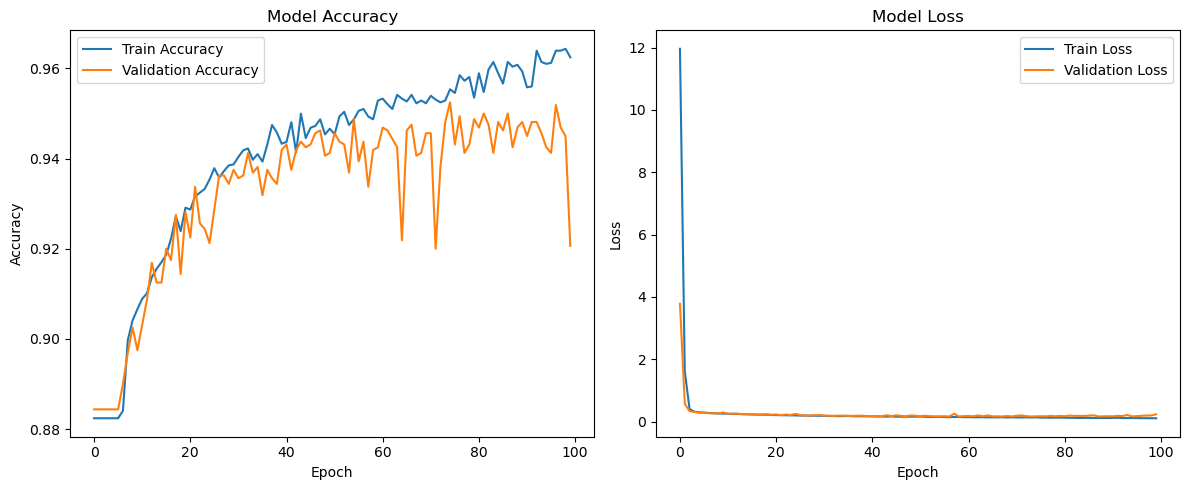

In [142]:
# Plot training & validation accuracy values
plt.figure(figsize=(12,5))

# Plot accuracy
plt.subplot(1,2,1)
plt.plot(history_regularized_droupout.history['accuracy'], label='Train Accuracy')
plt.plot(history_regularized_droupout.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot loss
plt.subplot(1,2,2)
plt.plot(history_regularized_droupout.history['loss'], label='Train Loss')
plt.plot(history_regularized_droupout.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()